FEATURE DETECTION ~ Corner
- [] Harris (akurat dan stabil, slow for real time) and SubPix
- [] FAST (Features form Accelerated Segment Test) cepet dan lingkaran gausa ada itung2an
- [] ORB (Oriented FAST and Rotated BRIEF)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

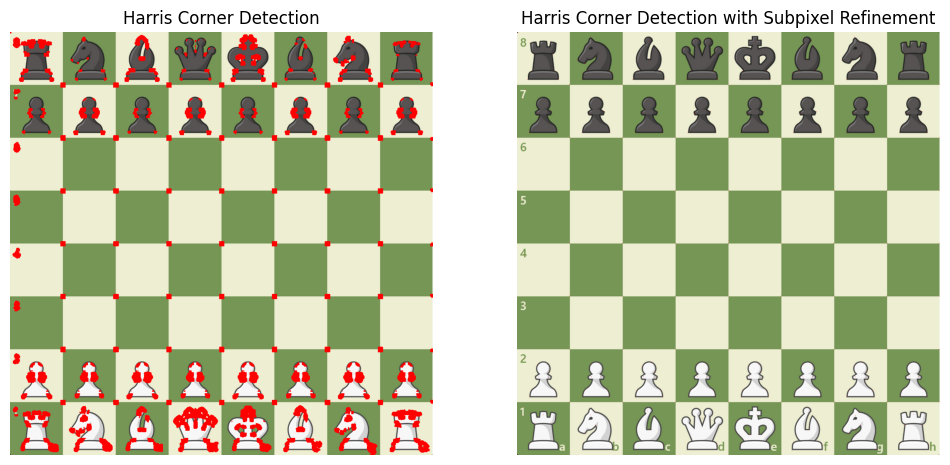

In [6]:
img = cv2.imread('img/chess.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # ubah ke grayscale
img_gray = np.float32(img_gray) # convert dari uint8 ke float32 supaya harris lebih stabil

# 1. Harris Corner
harris = cv2.cornerHarris(img_gray, blockSize=10, ksize=5, k=0.04)
# ksize = kernel yang dipake buath menghitung turunan gambarnya
# blockSize = menentukan ukuran area yang nanti nentuin area sudut atau bukan
# k = parameter bebas yang digunain dalam skor R di haris

img_result = img.copy()
img_result[harris > 0.01 * harris.max()] = [0, 0, 255] # jadi kondisi dimana skor harris yang lebih dr 0.01 * corner terkuat baru mau di display
img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB) # CVT karena mau pake plt buat nampilin gambar butuh format RGB ke BGR

# 2. Harris Corner with Suffix
_, thresh = cv2.threshold(harris, 0.01 * harris.max(), 255, cv2.THRESH_BINARY)
thresh = np.uint8(thresh)

# mau nyari titik centroid (pusat) dari setiap corner
_, _, _, corner_centroids = cv2.connectedComponentsWithStats(thresh)
corner_centroids = np.float32(corner_centroids)

# Criteria -> condition berhenti algoritma nya
criteria = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 100, 0.001)

corners = cv2.cornerSubPix(img_gray, corner_centroids, (5, 5), (-1, -1), criteria)
# winSize = 5 -> area pencarian centroid yg paling bagusnya
# zeroZone = -1 -> area sekitar winSize yang ga pengen dihitung buat mencegah noise.

with_subpix = img.copy() # deep copy gambar asli yg berwarna
corners = np.int16(corners) # buletin hasil float dari subpix biar jelas ketika jadi koordinat
for corner in corners: # iterasi buat dapetin koordinat x dan y dari corner buat jadi warna merah
    corner_x, corner_y = corner[0], corner[1]
    with_subpix[corner_y, corner_x] = [0, 0, 255]
with_subpix = cv2.cvtColor(with_subpix, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_result)
plt.title('Harris Corner Detection')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(with_subpix)
plt.title('Harris Corner Detection with Subpixel Refinement')
plt.axis('off')
plt.show()

['img1.jpeg', 'kenlab4.png', 'img3.jpg', 'img2.jpg']


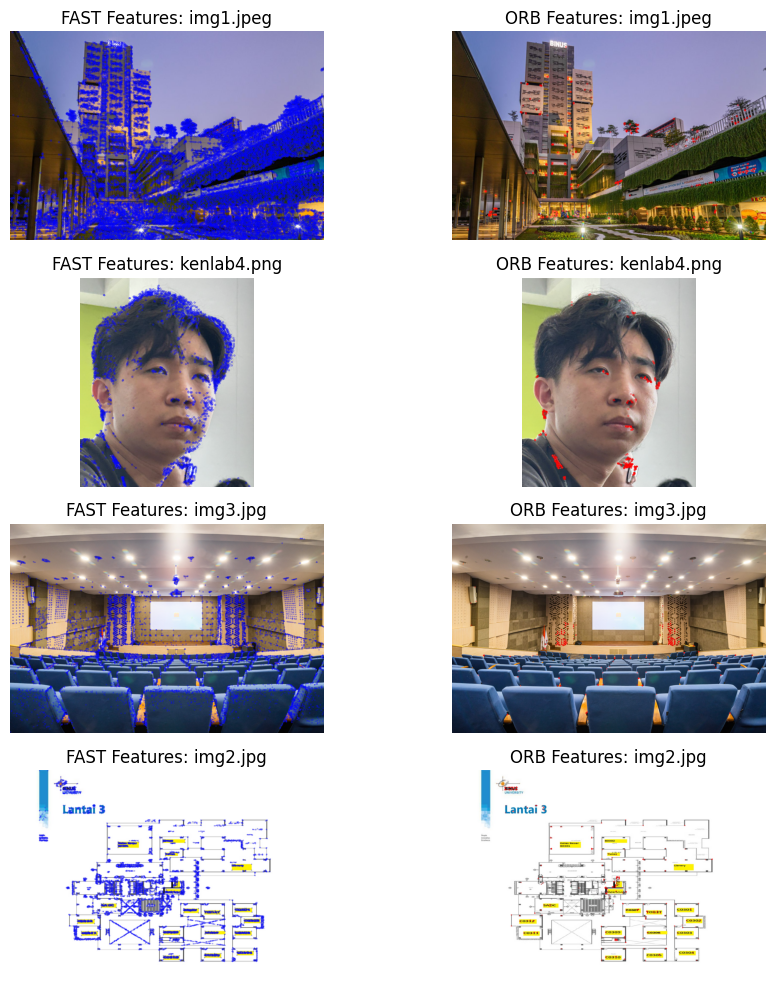

In [12]:
plt.figure(figsize=(10, 10))
folder_path = 'img/'
image_files = os.listdir(folder_path)
print(image_files)

for i, filename in enumerate(image_files):
    # img = cv2.imread(os.path.join(folder_path, filename))
    img = cv2.imread(folder_path + filename)

    fast = cv2.FastFeatureDetector_create()
    keypoints_fast = fast.detect(img)
    fast_res = cv2.drawKeypoints(img, keypoints_fast, None, color=(255, 0, 0))

    orb = cv2.ORB_create()
    keypoints_orb = orb.detect(img)
    orb_res = cv2.drawKeypoints(img, keypoints_orb, None, color=(0, 0, 255))

    fast_res = cv2.cvtColor(fast_res, cv2.COLOR_BGR2RGB)
    orb_res = cv2.cvtColor(orb_res, cv2.COLOR_BGR2RGB)

    plt.subplot(len(image_files), 2, i*2 + 1)
    plt.imshow(fast_res)
    plt.title('FAST Features: ' + filename)
    plt.axis('off')

    plt.subplot(len(image_files), 2, i*2 + 2)
    plt.imshow(orb_res)
    plt.title('ORB Features: ' + filename)
    plt.axis('off')

plt.tight_layout()
plt.show()